# Setup

### 01 Install required packages

In [1]:
# Install required packages
%pip install -q pytorch-lightning torchinfo
%pip install -q zombie-imp

### 02 Clone the repository

In [2]:
# Clone the repository to Colab environment
!git clone https://github.com/ilyarudyak/DL_projects_2026.git

fatal: destination path 'DL_projects_2026' already exists and is not an empty directory.


### 03 Switch to the project directory

In [4]:
import os

# Move into your specific project folder on the remote machine
os.chdir("/content/DL_projects_2026/01-sentiment-analysis")

# Print the directory contents to verify your python modules (.py files) are there
print("Current Working Directory:", os.getcwd())
print("\n=== Available Project Files ===")
!ls -la

Current Working Directory: /content/DL_projects_2026/01-sentiment-analysis

=== Available Project Files ===
total 932
drwxr-xr-x 7 root root   4096 Jul 21 14:48 .
drwxr-xr-x 4 root root   4096 Jul 21 14:34 ..
-rw-r--r-- 1 root root 186973 Jul 21 14:34 14_nlp_with_rnns_and_attention.ipynb
-rw-r--r-- 1 root root 594808 Jul 21 14:34 14-sentiment_analysis.ipynb
-rw-r--r-- 1 root root  16944 Jul 21 14:34 bpe_tokenizer.py
-rw-r--r-- 1 root root   8828 Jul 21 14:34 byte_bpe_tokenizer.py
-rw-r--r-- 1 root root  10547 Jul 21 14:34 bytes.ipynb
-rw-r--r-- 1 root root   1812 Jul 21 14:34 changes_in_trainer.md
drwxr-xr-x 2 root root   4096 Jul 21 14:34 configs
-rw-r--r-- 1 root root  18264 Jul 21 14:34 dataset.py
drwxr-xr-x 4 root root   4096 Jul 21 14:38 datasets
-rw-r--r-- 1 root root   1705 Jul 21 14:34 logging.csv
drwxr-xr-x 3 root root   4096 Jul 21 14:48 logs
-rw-r--r-- 1 root root  24608 Jul 21 14:34 model.py
drwxr-xr-x 2 root root   4096 Jul 21 14:34 printouts
drwxr-xr-x 2 root root   4096 

### 04 Import libraries

In [6]:
%load_ext autoreload
%autoreload 2

from dataset import IMDBConfig, IMDBData
from model import IMDBModelLP, IMDBModelLPPackedSeq, IMDBModelLPV2
from train import TrainerHighLevel

# Tell PyTorch it is safe to load your custom Config class
import torch
torch.serialization.add_safe_globals([IMDBConfig, IMDBData, IMDBModelLP])

# Set up logging format and level
import logging
# logging.basicConfig(format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging.basicConfig(format="%(levelname)s:%(name)s:  %(message)s")

### 05 Set logging levels [OPTIONAL]

In [5]:
# Specifically allow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.DEBUG)

In [ ]:
# Specifically disallow DEBUG messages ONLY from your project namespace
logging.getLogger("imdb").setLevel(logging.INFO)

### 06 Check hardware specifications [OPTIONAL]

In [6]:
# Check VM OS, RAM, and available disk space
print("=== Operating System ===")
!lsb_release -a

print("\n=== CPU Specifications ===")
!lscpu | grep "Model name\|CPU(s):"

print("\n=== System RAM ===")
!free -h

print("\n=== Disk Space ===")
!df -h /

=== Operating System ===
No LSB modules are available.
Distributor ID:	Ubuntu
Description:	Ubuntu 22.04.5 LTS
Release:	22.04
Codename:	jammy

=== CPU Specifications ===
CPU(s):                                  2
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
NUMA node0 CPU(s):                       0,1

=== System RAM ===
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.0Gi       7.7Gi       2.0Mi       3.9Gi        11Gi
Swap:             0B          0B          0B

=== Disk Space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /


### 07 Verify GPU Availability [OPTIONAL]

In [7]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("Running on CPU.")

PyTorch Version: 2.11.0+cpu
CUDA Available: False
Running on CPU.


### 08 End the session [OPTIONAL]

In [12]:
from google.colab import runtime
runtime.unassign()

### 09 Pull the latest changes from the repository [OPTIONAL]

In [5]:
!git pull

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 10 (delta 4), reused 10 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 10.80 KiB | 2.16 MiB/s, done.
From https://github.com/ilyarudyak/DL_projects_2026
   c9504a6..5e73a5e  main       -> origin/main
Updating c9504a6..5e73a5e
Fast-forward
 01-sentiment-analysis/configs/base_config.yaml     |   2 +-
 .../sentiment_analysis_colab_v2.ipynb              | 566 ++++++++++++++++++++-
 2 files changed, 550 insertions(+), 18 deletions(-)


# 01 IMDB Dataset

In [8]:
# Create config file for IMDB dataset
config_file = "configs/base_config.yaml"
config = IMDBConfig.from_yaml(config_file)

In [9]:
# Create an instance of the IMDBData class
data = IMDBData(config=config)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


In [10]:
# Create loaders for the training and validation datasets
train_loader, val_loader = data.get_loaders()

# 02 Training the model

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the 

🚀 Using hardware accelerator: cpu


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.997


Epoch   1 | Train Loss: 1.0484 | Train Acc: 0.5075 | Val Loss: 0.9972 | Val Acc: 0.5100


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.



✅ Training finished. Loading best model State

🏆 Best Model Metrics (from Epoch 1):
├─ Train Loss: 1.0484
├─ Train Acc:  0.5075
├─ Val Loss:   0.9972
└─ Val Acc:    0.5100


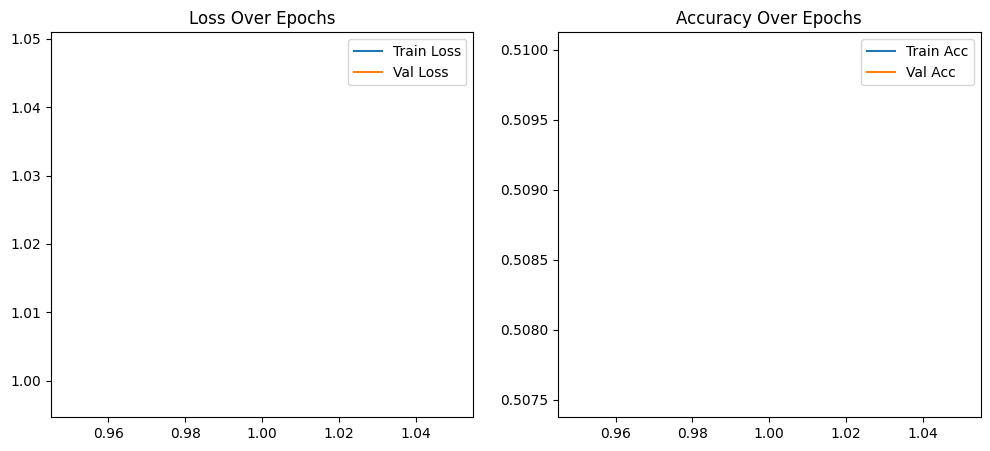

In [11]:
# Specify the config file
config_name = "base_config"

# Create an instance of a TrainerHighLevel with a toy dataset
trainer = TrainerHighLevel(config_name=config_name, 
                           data_limit=1000, # Use the toy dataset
                           model_class=IMDBModelLPPackedSeq,
                           device='auto'
                           )

# Fit the model using the trainer
trainer.fit()

# Plot the training and validation loss curves
trainer.plot_training_curves()